# Case study 2:  Comparing transport modes, Tallinn, Estonia

ASDF


In [1]:
import itertools
import urllib.parse

import contextily
import geopandas
import h3
import matplotlib.pyplot
import numpy
import pandas
import shapely
import r5py

In [2]:
BOUNDING_BOX = shapely.box(24.5, 59.35, 25.0, 59.5)

### 1. Create a hexagonal grid covering the city

asdf asdf

In [3]:
h3_cells = h3.geo_to_cells(BOUNDING_BOX, 8)

hexgrid = geopandas.GeoDataFrame(
    {
        "id": h3_cells,
        "geometry": [h3.cells_to_h3shape([h3_cell]) for h3_cell in h3_cells],
    },
    crs="EPSG:4326",
).to_crs("EPSG:3857")
hexgrid.explore()

### 2. Initialise a transport network model with open data

Next, we create a new model of the transport network of the city. For this, we need two data sources, both available openly:

- an OpenStreetMap (OSM) extract, with details on the street, bicycle, and footpath network, downloaded from BBBIKE (https://download.bbbike.org/osm/), under the Open Database License (https://opendatacommons.org/licenses/odbl/summary/)
- a public transport schedule in GTFS format, provided by ADSF under a Creative Commons Attribution 4.0 license (https://foo.bar/)

In [4]:
transport_network = r5py.TransportNetwork(
    "https://download.bbbike.org/osm/bbbike/Tallinn/Tallinn.osm.pbf",  # OpenStreetMap extract
    ["https://eu-gtfs.remix.com/tallinn.zip"],  # public transport schedule
)


In [5]:
origins = hexgrid.copy()
origins["geometry"] = transport_network.snap_to_network(origins["geometry"].centroid, 200)
origins = origins[~origins["geometry"].is_empty]

In [6]:
hexgrid = hexgrid[hexgrid["id"].isin(origins["id"])]
hexgrid.explore()

In [7]:
len(origins)

579

### X. Compute travel times 

asdfasdf

In [8]:
travel_time_matrices = {}
for transport_mode in [
    r5py.TransportMode.BICYCLE,
    r5py.TransportMode.CAR,
    r5py.TransportMode.TRANSIT,
    r5py.TransportMode.WALK,
]:
    travel_time_matrices[f"{transport_mode.value}"] = (
        r5py.TravelTimeMatrix(
            transport_network, 
            origins, 
            transport_modes=[transport_mode],
        )
        .set_index(["from_id", "to_id"])
        .replace(0, numpy.nan)
    )

### 5. Interpret and visualise results

ASDF

#### Distribution of travel times of all trips

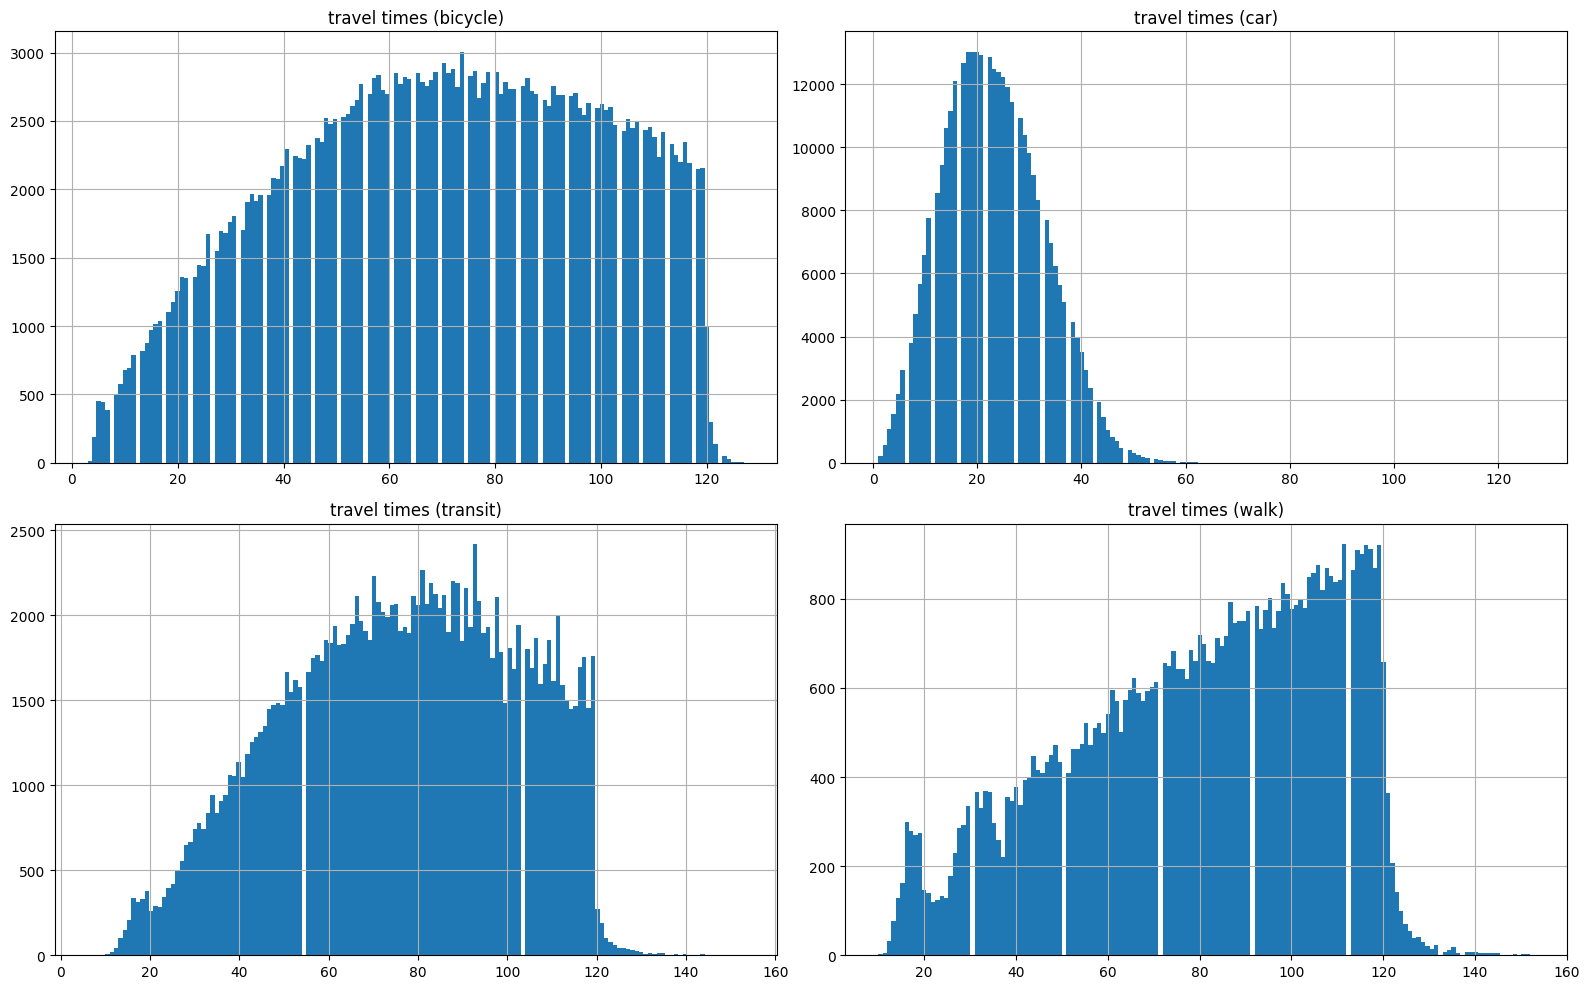

In [10]:
COLUMNS = 2
ROWS = 2
figure, axes = matplotlib.pyplot.subplots(COLUMNS, ROWS, figsize=(16, 10), layout="tight")

for (x, y), transport_mode in zip(itertools.product(range(COLUMNS), range(ROWS)), travel_time_matrices):
    travel_time_matrices[transport_mode].hist(ax=axes[x][y], bins=150)
    axes[x][y].set_title(f"travel times ({transport_mode.lower()})")

#### Mean travel times over the entire city

In [11]:
median_travel_times = {}
for transport_mode in travel_time_matrices:
    median_travel_times[transport_mode] = travel_time_matrices[transport_mode].reset_index().set_index("from_id").groupby("to_id").median()

In [12]:
median_travel_times["BICYCLE"]

,travel_time
to_id,
88089b0a01fffff,78.0
88089b0a03fffff,76.5
88089b0a05fffff,78.0
88089b0a07fffff,76.0
88089b0a09fffff,77.0
...,...
88089bced5fffff,66.0
88089bced7fffff,64.0
88089bced9fffff,62.0


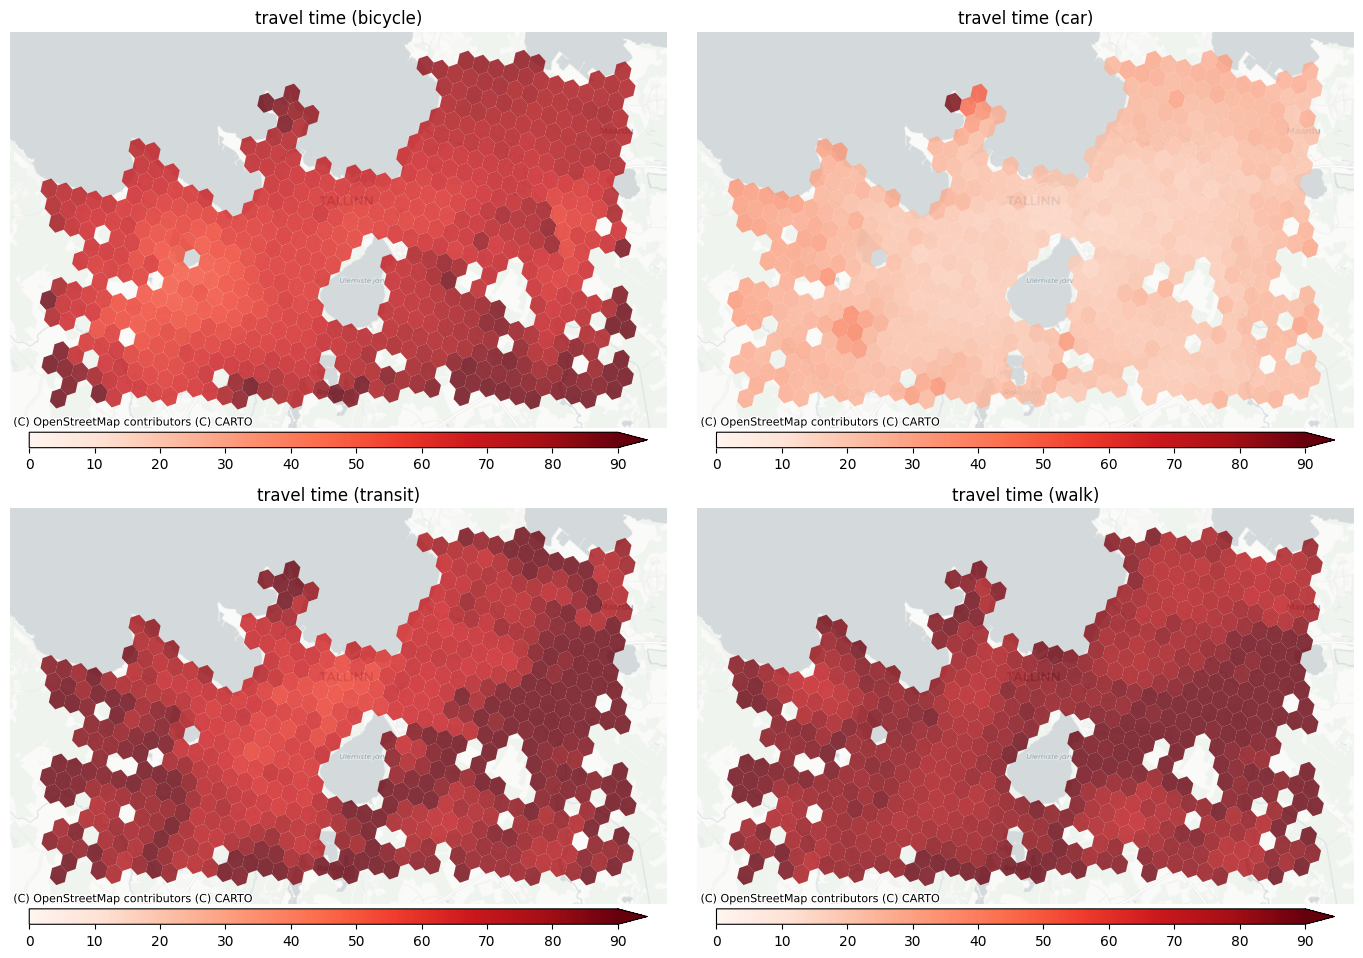

In [13]:
COLUMNS = 2
ROWS = 2
figure, axes = matplotlib.pyplot.subplots(COLUMNS, ROWS, figsize=(16, 10), layout="tight")

for (x, y), transport_mode in zip(itertools.product(range(COLUMNS), range(ROWS)), median_travel_times):
    data = hexgrid.set_index("id").join(median_travel_times[transport_mode]).rename(columns={"travel_time": f"travel time ({transport_mode})"})
    data[f"travel time ({transport_mode})"].describe()
    data.plot(
        column=f"travel time ({transport_mode})", 
        cmap="Reds", 
        vmin=0.0,
        vmax=90.0,
        alpha=0.8,
        ax=axes[x][y],
        legend=True,
        legend_kwds={
            "location": "bottom",
            "aspect": 40,
            "shrink": 0.7,
            "pad": 0.01,
            "extend": "max",
        }
    )
    contextily.add_basemap(axes[x][y], source=contextily.providers.CartoDB.Positron)
    axes[x][y].set_title(f"travel time ({transport_mode.lower()})")
    axes[x][y].set_axis_off()